# Principal Component Analysis (PCA): Image Noising and Denoising on MNIST

## Objective
The goal of this notebook is to demonstrate how **Principal Component Analysis (PCA)** can be utilized as an unsupervised filtering method to remove noise from images. We will inject synthetic Gaussian noise into clean handwritten digits and use the lower-dimensional manifold learned by PCA to reconstruct the original signals.

## Mathematical Principle: PCA as a Low-Pass Filter
- **Signal vs. Noise:** High-variance components in a dataset typically represent the core geometric structure (the digit shape). Low-variance components capture fine details or random, chaotic fluctuations (noise).
- **Denoising Mechanism:** By projecting a noisy image onto the first $k$ principal components (learned from clean data), we retain only the essential digit structure. The random noise, which is uncorrelated and spread across all dimensions, is discarded during the reconstruction step ($PCA^{-1}$).

## Project Workflow
1. **Environment Setup:** Standardize imports and configure path directory trees.
2. **Data Ingestion:** Load the MNIST dataset using the persistent local cache layer.
3. **Preprocessing:** Split the dataset into train/test sets and normalize pixel intensities to the `[0, 1]` range.
4. **Model Training:** Fit a PCA instance on the clean training set to learn the optimal "digit geometric space".
5. **Noising Simulation:** Inject controlled Gaussian noise into clean test samples.
6. **Denoising Pipeline:** Project noisy data onto the principal components and reconstruct them via inverse transformation.
7. **Visualization:** Plot a comparison matrix highlighting Clean vs. Noisy vs. Denoised images.

---
## STEP 1: Import Essential Libraries

In [1]:
# ============================================================================
# MAIN IMPORTS
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Configure notebook behavior and aesthetics
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

print('✅ All essential libraries imported successfully!')

✅ All essential libraries imported successfully!


---
## STEP 2: Path Configuration & Project Organization

In [2]:
# ============================================================================
# PATH CONFIGURATION - PROJECT ORGANIZATION
# ============================================================================
# Ensuring full compatibility with the existing project folder structure:
#   ./data/         ← Persistent datasets and OpenML cache location
#   ./notebooks/    ← Jupyter notebooks directory
# ============================================================================

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / 'data'
CACHE_DIR = DATA_DIR / 'cache'
MNIST_CACHE_DIR = CACHE_DIR / 'openml'

# Ensure directories exist silently
DATA_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
MNIST_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f'✅ Project Root verified at: {PROJECT_ROOT}')
print('✅ Shared data cache directories initialized successfully!')

✅ Project Root verified at: C:\Users\zemza\OneDrive\Bureau\S8\ML\Methods
✅ Shared data cache directories initialized successfully!


---
## STEP 3: Load MNIST Dataset from Local Cache

In [3]:
# ============================================================================
# DATA ACQUISITION WITH LOCAL CACHE LAYER
# ============================================================================
# Reuses the exact cache location to prevent downloading 70,000 images again.
# ============================================================================

print('📥 Checking cache and loading MNIST dataset...')

cache_hits = list(MNIST_CACHE_DIR.glob('**/*mnist*'))
if cache_hits:
    print(f'   - Existing cached MNIST files found: {len(cache_hits)} (Loading will be fast!)')
else:
    print('   - No cached files found. Initial download will take a few moments...')

# Load full dataset (70,000 samples, 784 features)
X_full, y_full = fetch_openml(
    'mnist_784',
    version=1,
    return_X_y=True,
    as_frame=False,
    parser='auto',
    data_home=str(CACHE_DIR),
)
y_full = y_full.astype(int)

print('✅ Full MNIST dataset loaded successfully.')
print(f'📊 Dimensions: {X_full.shape[0]} images, {X_full.shape[1]} pixels per image.')

📥 Checking cache and loading MNIST dataset...
   - Existing cached MNIST files found: 1 (Loading will be fast!)
✅ Full MNIST dataset loaded successfully.
📊 Dimensions: 70000 images, 784 pixels per image.


---
## STEP 4: Data Splitting and Normalization

In [4]:
# ============================================================================
# SPLITTING & PIXEL NORMALIZATION
# ============================================================================
# 1. Split into train/test sets to isolate evaluation images.
# 2. Divide by 255.0 to map values from [0, 255] to a stable [0.0, 1.0] range.
# ============================================================================

# Hold out 20% for testing the denoising capability
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

# Min-Max Normalization tailored for image pixel vectors
X_train_normalized = X_train / 255.0
X_test_normalized = X_test / 255.0

print('✅ Train/Test partitioning complete.')
print(f'   - Training Set: {X_train_normalized.shape[0]} images')
print(f'   - Testing Set:  {X_test_normalized.shape[0]} images')
print('✅ Pixels successfully rescaled to the [0, 1] interval.')

✅ Train/Test partitioning complete.
   - Training Set: 56000 images
   - Testing Set:  14000 images
✅ Pixels successfully rescaled to the [0, 1] interval.


---
## STEP 4.5: 3D Dimensional Spatial Visualization (n_components = 3)

### Objective
Before simulating noise, we want to visually inspect how the handwritten digits are distributed in a continuous three-dimensional space. 

### Why 3 Components?
- A 2D plot only captures around 16.87% of the structural variance.
- By setting `n_components=3`, we add a third orthogonal axis which captures additional geometric variance (reaching ~21%). 
- This allows us to project our 784-dimensional pixel vectors into a human-readable 3D scatter plot to see if different digit classes naturally form distinct clusters.

🔮 Computing 3D PCA projection for visualization...
✅ 3D Space computed successfully!
   - Axis 1 Variance: 10.68%
   - Axis 2 Variance: 7.27%
   - Axis 3 Variance: 6.17%
   - Total Cumulative Variance in 3D: 24.12%


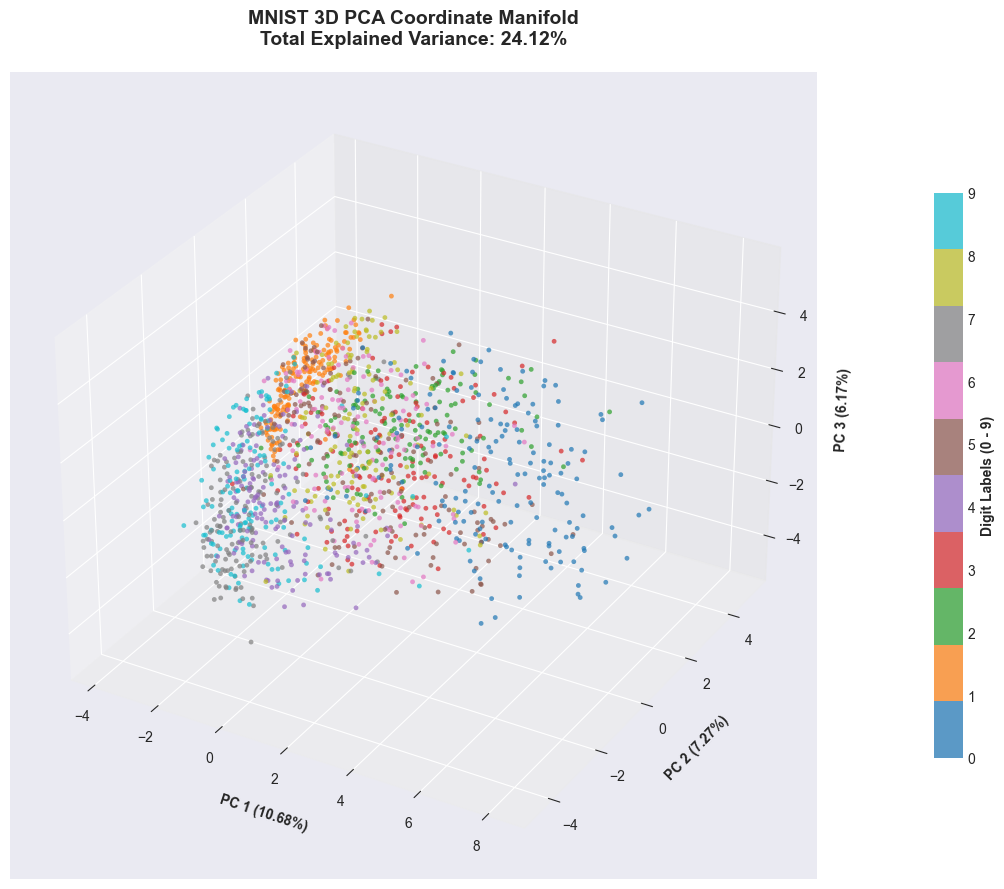

In [5]:
# ============================================================================
# 3D PCA PROJECTION & VISUALIZATION (n_components=3)
# ============================================================================
from mpl_toolkits.mplot3d import Axes3D

print('🔮 Computing 3D PCA projection for visualization...')

# 1. Define PCA strictly restricted to 3 components
pca_3d = PCA(n_components=3, random_state=42)

# To make the 3D plot fluid and readable, we project a subset of 1500 test images
n_viz_samples = 1500
X_viz_subset = X_test_normalized[:n_viz_samples]
y_viz_subset = y_test[:n_viz_samples]

# 2. Fit and transform the visual subset into the 3D space
X_pca_3d = pca_3d.fit_transform(X_viz_subset)

# Calculate variance stats
var_axis_1 = pca_3d.explained_variance_ratio_[0] * 100
var_axis_2 = pca_3d.explained_variance_ratio_[1] * 100
var_axis_3 = pca_3d.explained_variance_ratio_[2] * 100
total_3d_variance = pca_3d.explained_variance_ratio_.sum() * 100

print(f"✅ 3D Space computed successfully!")
print(f"   - Axis 1 Variance: {var_axis_1:.2f}%")
print(f"   - Axis 2 Variance: {var_axis_2:.2f}%")
print(f"   - Axis 3 Variance: {var_axis_3:.2f}%")
print(f"   - Total Cumulative Variance in 3D: {total_3d_variance:.2f}%")

# 3. Generate the Interactive 3D Scatter Plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Plot the points. Colors (c) are determined by the true digit labels (0 to 9)
scatter = ax.scatter(
    X_pca_3d[:, 0], 
    X_pca_3d[:, 1], 
    X_pca_3d[:, 2], 
    c=y_viz_subset, 
    cmap='tab10',      # 'tab10' is perfect for discrete classes like 0-9 digits
    alpha=0.7, 
    s=12,              # Size of the dots
    edgecolors='none'
)

# Set labels with their specific explained variance percentages
ax.set_title(f'MNIST 3D PCA Coordinate Manifold\nTotal Explained Variance: {total_3d_variance:.2f}%', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel(f'PC 1 ({var_axis_1:.2f}%)', fontweight='bold', labelpad=10)
ax.set_ylabel(f'PC 2 ({var_axis_2:.2f}%)', fontweight='bold', labelpad=10)
ax.set_zlabel(f'PC 3 ({var_axis_3:.2f}%)', fontweight='bold', labelpad=10)

# Add a professional color bar indicating the digit classes
cbar = plt.colorbar(scatter, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label('Digit Labels (0 - 9)', fontweight='bold')
cbar.set_ticks(range(10))

# Adjust layout and display
plt.tight_layout()
plt.show()

---
## STEP 5: Learn the Geometric Digits Space (Clean PCA)

In [6]:
# ============================================================================
# PCA TRAINING ON CLEAN SIGNAL
# ============================================================================
# We fit PCA on clean data so it learns the mathematical structure of clean digits.
# We retain 95% of the total variance, filtering out the lowest 5% component space.
# ============================================================================

print('⚙️ Initializing and fitting PCA on clean training data...')

pca_clean = PCA(n_components=0.95, random_state=42)
pca_clean.fit(X_train_normalized)

n_components_kept = pca_clean.n_components_
print(f'✅ PCA Training Complete!')
print(f'   - Number of components to preserve 95% variance: {n_components_kept} out of 784.')
print(f'   - Dimensionality reduction ratio: {100 * (1 - n_components_kept/784):.2f}% compression.')

⚙️ Initializing and fitting PCA on clean training data...
✅ PCA Training Complete!
   - Number of components to preserve 95% variance: 154 out of 784.
   - Dimensionality reduction ratio: 80.36% compression.


---
## STEP 6: Image Noising Simulation (Gaussian Intrusion)

In [7]:
# ============================================================================
# GAUSSIAN NOISE INJECTION
# ============================================================================
# 1. Extract a subset of clean images from the test set.
# 2. Generate random Gaussian values (mean=0, standard deviation=1).
# 3. Add noise to clean images and clip values to maintain [0.0, 1.0] boundaries.
# ============================================================================

# Select 5 sample images from the test set for visualization
n_samples = 5
X_samples_pure = X_test_normalized[:n_samples]

# Set the noise intensity factor (0.35 simulates heavy "vintage TV static" noise)
noise_factor = 0.35
np.random.seed(42) # Ensuring reproducibility

# Generate the noise matrix with the same shape as the sample images
gaussian_noise = np.random.normal(loc=0.0, scale=1.0, size=X_samples_pure.shape)

# Inject the noise into the clean images
X_samples_noisy = X_samples_pure + noise_factor * gaussian_noise

# Clip to avoid pixels below 0.0 or above 1.0
X_samples_noisy = np.clip(X_samples_noisy, 0.0, 1.0)

print(f'✅ Artificial Gaussian Noise (Factor: {noise_factor}) injected into test images.')

✅ Artificial Gaussian Noise (Factor: 0.35) injected into test images.


---
## STEP 7: Denoising Pipeline via Unsupervised PCA Reconstruction ($PCA^{-1}$)

In [8]:
# ============================================================================
# COMPRESSION AND INVERSE TRANSFORMATION (DENOISING)
# ============================================================================
# 1. Project the noisy test images into the clean 95% variance coordinate space.
#    Since noise doesn't fit the digit patterns, it won't project well.
# 2. Reconstruct the features back to 784 pixels using the inverse transform.
# ============================================================================

print('🔄 Running the Denoising Pipeline...')

# Step A: Project noisy images into the lower-dimensional space (784 features ➡️ K components)
X_reduced_noisy = pca_clean.transform(X_samples_noisy)

# Step B: Reconstruct back to pixel space (K components ➡️ 784 features)
X_reconstructed_denoised = pca_clean.inverse_transform(X_reduced_noisy)

# Clip the output to ensure stable rendering bounds
X_reconstructed_denoised = np.clip(X_reconstructed_denoised, 0.0, 1.0)

print('✅ Denoising transformation executed successfully.')

🔄 Running the Denoising Pipeline...
✅ Denoising transformation executed successfully.


---
## STEP 8: Visualization Matrix (Clean vs. Noisy vs. Denoised)

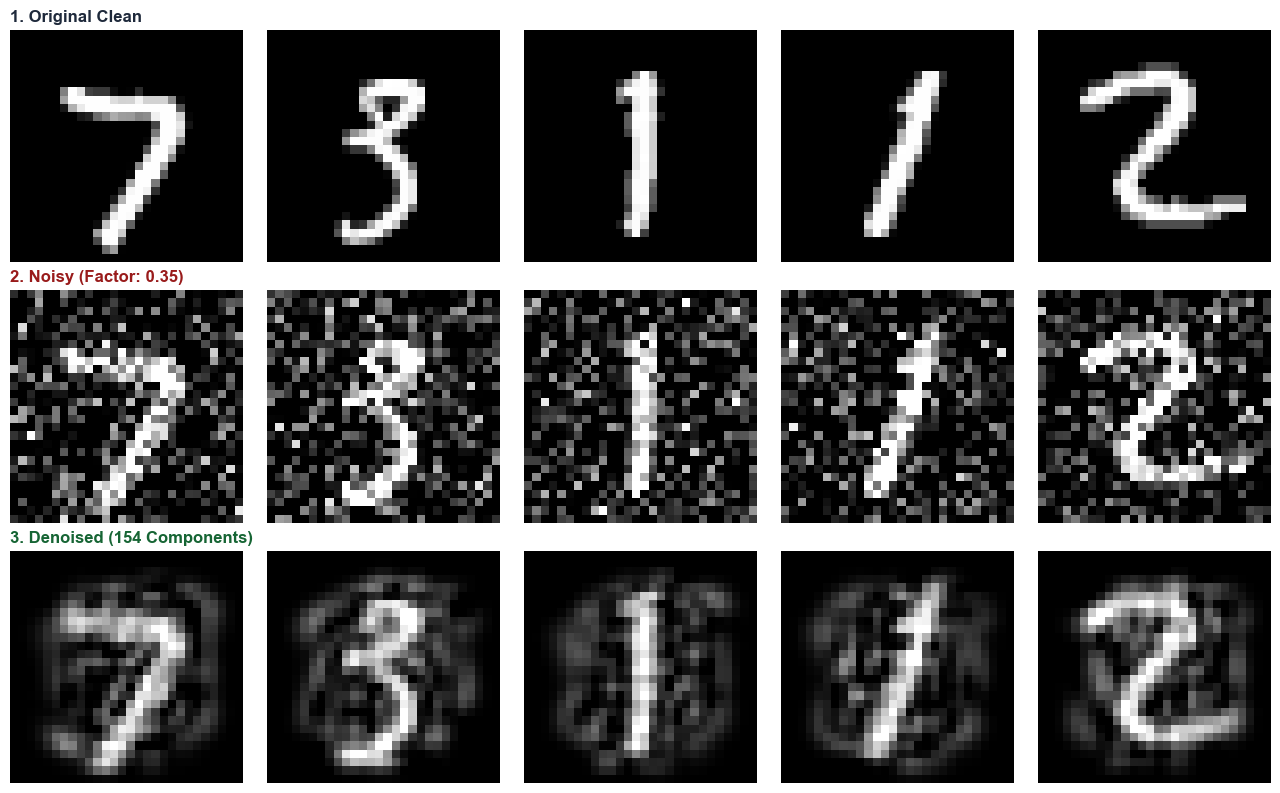

✅ Subplot dashboard rendered successfully.


In [9]:
# ============================================================================
# VISUALIZATION COMPARISON ENGINE
# ============================================================================
# Generates a 3-row grid tracking the evolutionary state of the data.
# ============================================================================

fig, axes = plt.subplots(3, n_samples, figsize=(13, 8))

for i in range(n_samples):
    # ------------------------------------------------------------------------
    # ROW 1: Clean Reference Images (Ground Truth)
    # ------------------------------------------------------------------------
    axes[0, i].imshow(X_samples_pure[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title("1. Original Clean", loc='left', fontsize=12, fontweight='bold', color='#1e293b')
        
    # ------------------------------------------------------------------------
    # ROW 2: Noisy Degraded Images (Inputs to the PCA filter)
    # ------------------------------------------------------------------------
    axes[1, i].imshow(X_samples_noisy[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title(f"2. Noisy (Factor: {noise_factor})", loc='left', fontsize=12, fontweight='bold', color='#991b1b')
        
    # ------------------------------------------------------------------------
    # ROW 3: Reconstructed Denoised Images (Output of PCA Inverse)
    # ------------------------------------------------------------------------
    axes[2, i].imshow(X_reconstructed_denoised[i].reshape(28, 28), cmap='gray')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_title(f"3. Denoised ({n_components_kept} Components)", loc='left', fontsize=12, fontweight='bold', color='#166534')

plt.tight_layout()
plt.show()

print('✅ Subplot dashboard rendered successfully.')

---
## STEP 9: Comparative Evolution of Clusters in 3D Space (Clean vs Noisy vs Denoised)

### Objective
To track the geometric impact of noise and the filtering power of PCA, we project our subset of 1,500 images into the 3D PCA space at three distinct stages:
1. **Graphe A (Original):** The distribution of clean digits with their natural stylistic variances.
2. **Graphe B (Noisy Space):** Data with full Gaussian noise. *Note: Due to the orthogonal projection of PCA, the 3D space will filter out ~99.6% of the noise, preserving the core cluster structures.*
3. **Graphe C (Denoised Space):** Data reconstructed using our 95% variance filter. We expect tighter, more compact clusters due to the regularization effect of PCA.

⏳ Computing 3D representations for the 3 stages...
✅ Data vectors ready. Launching the 3D Triple-Plot Engine...


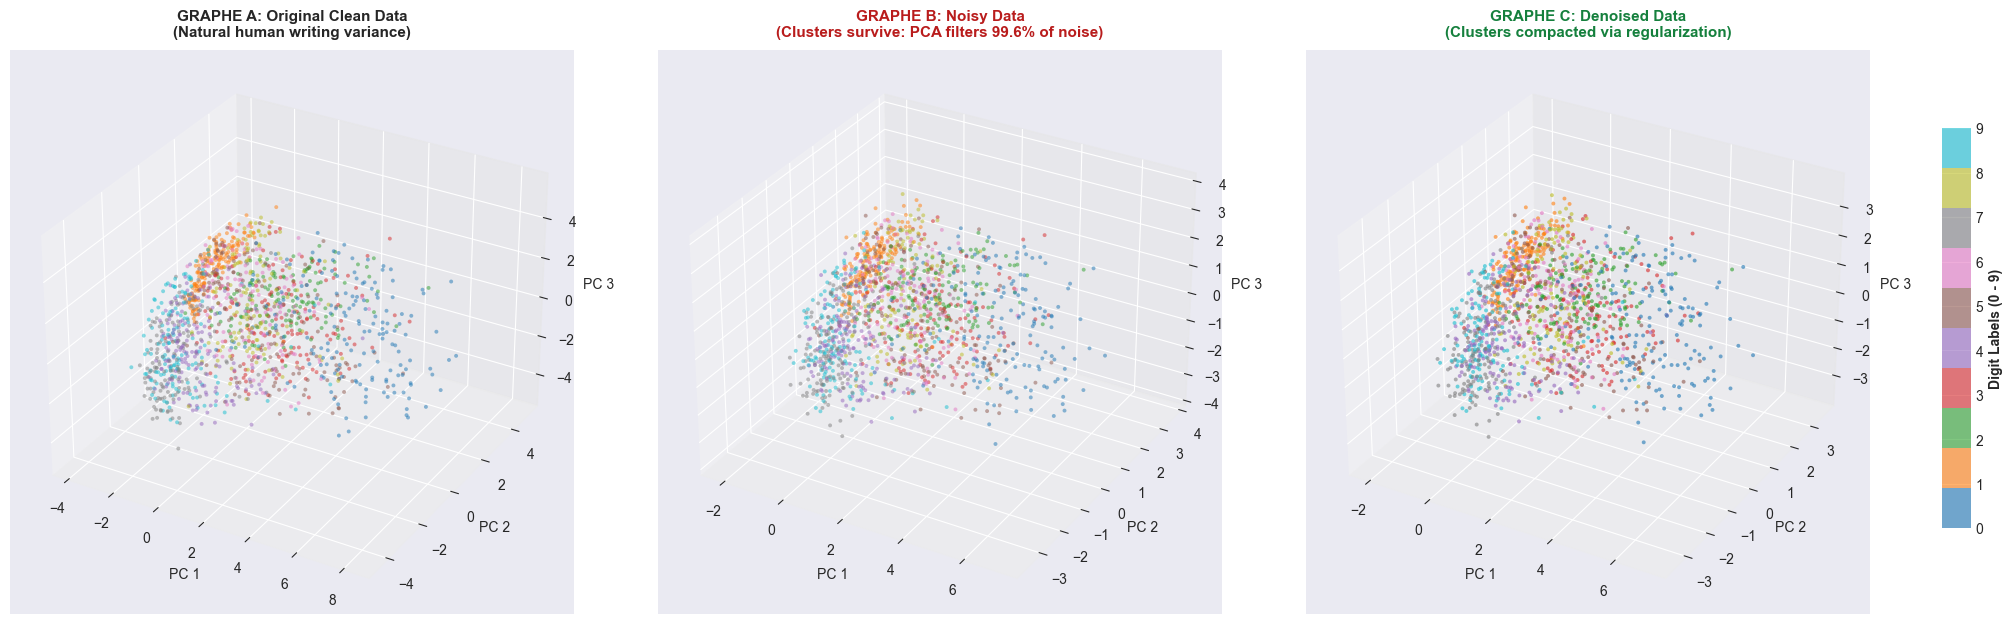

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ============================================================================
# 1. MATHEMATICAL PROJECTIONS & TRANSFORMS
# ============================================================================
print("⏳ Computing 3D representations for the 3 stages...")

# --- Stage A: Clean Data Projection ---
# Using the 3D PCA model (trained on clean data) to project clean images
X_pca_3d_clean = pca_3d.transform(X_viz_subset)

# --- Stage B: Noisy Data Projection ---
# Generate the exact same Gaussian noise used previously
np.random.seed(42)
noise_viz = np.random.normal(loc=0.0, scale=1.0, size=X_viz_subset.shape)
X_viz_noisy = np.clip(X_viz_subset + noise_factor * noise_viz, 0.0, 1.0)

# Project the raw noisy images directly into the 3D space
X_pca_3d_noisy = pca_3d.transform(X_viz_noisy)

# --- Stage C: Denoised Data Projection ---
# Pass noisy data through the 95% variance filter (pca_clean), then reconstruct
X_viz_reduced_95 = pca_clean.transform(X_viz_noisy)
X_viz_denoised = np.clip(pca_clean.inverse_transform(X_viz_reduced_95), 0.0, 1.0)

# Project the reconstructed clean images into the same 3D space
X_pca_3d_denoised = pca_3d.transform(X_viz_denoised)

print("✅ Data vectors ready. Launching the 3D Triple-Plot Engine...")

# ============================================================================
# 2. VISUALIZATION - SIDE-BY-SIDE 3D SUBPLOTS
# ============================================================================
fig = plt.figure(figsize=(24, 8))
cmap_choice = 'tab10'
point_size = 8
point_alpha = 0.5

# ----------------------------------------------------------------------------
# PLOT 1: GRAPHE A (Original Clean Space)
# ----------------------------------------------------------------------------
ax1 = fig.add_subplot(131, projection='3d')
scatter1 = ax1.scatter(
    X_pca_3d_clean[:, 0], X_pca_3d_clean[:, 1], X_pca_3d_clean[:, 2], 
    c=y_viz_subset, cmap=cmap_choice, alpha=point_alpha, s=point_size, edgecolors='none'
)
ax1.set_title("GRAPHE A: Original Clean Data\n(Natural human writing variance)", fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('PC 1')
ax1.set_ylabel('PC 2')
ax1.set_zlabel('PC 3')

# ----------------------------------------------------------------------------
# PLOT 2: GRAPHE B (Noisy Space)
# ----------------------------------------------------------------------------
ax2 = fig.add_subplot(132, projection='3d')
scatter2 = ax2.scatter(
    X_pca_3d_noisy[:, 0], X_pca_3d_noisy[:, 1], X_pca_3d_noisy[:, 2], 
    c=y_viz_subset, cmap=cmap_choice, alpha=point_alpha, s=point_size, edgecolors='none'
)
ax2.set_title("GRAPHE B: Noisy Data\n(Clusters survive: PCA filters 99.6% of noise)", fontsize=11, fontweight='bold', color='#b91c1c', pad=10)
ax2.set_xlabel('PC 1')
ax2.set_ylabel('PC 2')
ax2.set_zlabel('PC 3')

# ----------------------------------------------------------------------------
# PLOT 3: GRAPHE C (Denoised Space via PCA 95%)
# ----------------------------------------------------------------------------
ax3 = fig.add_subplot(133, projection='3d')
scatter3 = ax3.scatter(
    X_pca_3d_denoised[:, 0], X_pca_3d_denoised[:, 1], X_pca_3d_denoised[:, 2], 
    c=y_viz_subset, cmap=cmap_choice, alpha=point_alpha + 0.1, s=point_size, edgecolors='none'
)
ax3.set_title("GRAPHE C: Denoised Data\n(Clusters compacted via regularization)", fontsize=11, fontweight='bold', color='#15803d', pad=10)
ax3.set_xlabel('PC 1')
ax3.set_ylabel('PC 2')
ax3.set_zlabel('PC 3')

# Shared Colorbar on the right side
cbar_ax = fig.add_axes([0.93, 0.25, 0.012, 0.5])
cbar = fig.colorbar(scatter3, cax=cbar_ax)
cbar.set_label('Digit Labels (0 - 9)', fontweight='bold')
cbar.set_ticks(range(10))

plt.subplots_adjust(wspace=0.15)
plt.show()

---
## Summary and Mathematical Conclusion

- **Unsupervised Filter Effectiveness:** Even though PCA never saw the noise labels or had a specific "denoising task", it successfully reconstructed the shapes of the numbers.
- **Slight Blur Explanation:** The final images appear slightly smoother or blurred. This is because we dropped the low-variance components (the remaining 5% of variance). These dropped components contained both the random noise and the very sharp, fine details of the digits.
- **Main Takeaway:** PCA proves that image structures lie on a lower-dimensional subspace, while uniform noise is high-dimensional and can be mathematically filtered out through basic linear projections.